cargar los datos y ver la distribución de las notas de los restaurantes

¡Dataset cargado! Tenemos 1083397 restaurantes y 42 columnas.

Resumen de la nota media (avg_rating):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ avg_rating │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 986761.0   │
│ null_count ┆ 96636.0    │
│ mean       ┆ 4.035943   │
│ std        ┆ 0.713694   │
│ min        ┆ 1.0        │
│ 25%        ┆ 3.5        │
│ 50%        ┆ 4.0        │
│ 75%        ┆ 4.5        │
│ max        ┆ 5.0        │
└────────────┴────────────┘


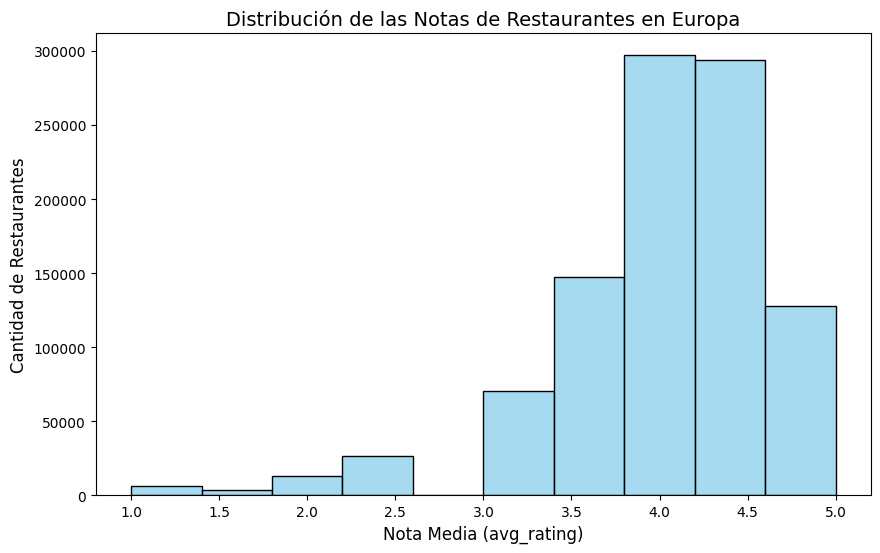

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos el CSV desde la carpeta data
ruta_csv = "../data/tripadvisor_european_restaurants.csv"
df = pl.read_csv(ruta_csv, ignore_errors=True)

print(f"¡Dataset cargado! Tenemos {df.height} restaurantes y {df.width} columnas.")

# 2. Vamos a ver un resumen estadístico de la variable que queremos predecir (avg_rating)
print("\nResumen de la nota media (avg_rating):")
print(df.select("avg_rating").describe())

# 3. Hacemos un histograma para ver cómo vota la gente
notas_pandas = df.select("avg_rating").drop_nulls().to_pandas() # Pasamos a pandas solo para el gráfico


plt.figure(figsize=(10, 6))
# Ponemos kde=False para quitar las ondas
sns.histplot(notas_pandas['avg_rating'], bins=10, kde=False, color='skyblue')
plt.title('Distribución de las Notas de Restaurantes en Europa', fontsize=14)
plt.xlabel('Nota Media (avg_rating)', fontsize=12)
plt.ylabel('Cantidad de Restaurantes', fontsize=12)
plt.show()

Vamos a hacer un "Boxplot" (diagrama de caja) para ver si los restaurantes caros tienen mejores notas que los baratos:

Generando EDA Profesional V2 (Sin Data Leakage y Sin Multicolinealidad)...


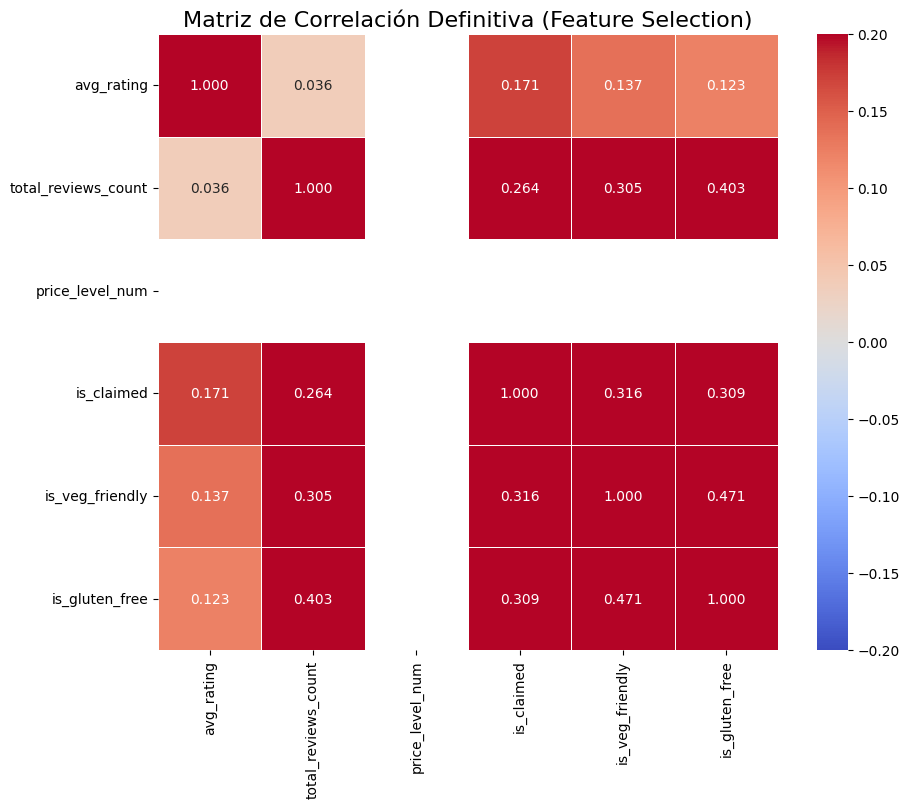

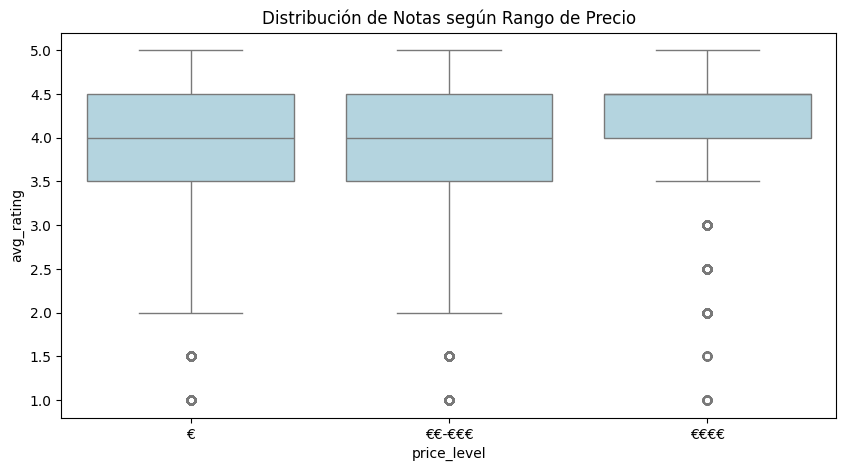

In [10]:
# 4. ¿El precio afecta a la nota? Boxplot de avg_rating según price_level

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando EDA Profesional V2 (Sin Data Leakage y Sin Multicolinealidad)...")

# 1. Transformamos los precios a números
df_model = df.with_columns(
    pl.when(pl.col("price_level") == "$").then(1)
    .when(pl.col("price_level") == "$$ - $$$").then(2)
    .when(pl.col("price_level") == "$$$$").then(3)
    .otherwise(0).alias("price_level_num")
)

# 2. Transformamos variables categóricas clave en Binarias (1 y 0)
df_model = df_model.with_columns([
    # Si el restaurante está reclamado por el dueño
    pl.when(pl.col("claimed") == "Claimed").then(1).otherwise(0).alias("is_claimed"),
    
    # Opciones de dieta (Asumimos que 'Y' es sí)
    pl.when(pl.col("vegetarian_friendly") == "Y").then(1).otherwise(0).alias("is_veg_friendly"),
    pl.when(pl.col("gluten_free") == "Y").then(1).otherwise(0).alias("is_gluten_free")
])

# 3. Seleccionamos las columnas para nuestra Matriz
cols_numericas = [
    "avg_rating", 
    "total_reviews_count", 
    "price_level_num", 
    "is_claimed", 
    "is_veg_friendly", 
    "is_gluten_free"
]

# Filtramos nulos en la nota objetivo y pasamos a Pandas para el Heatmap
df_corr = df_model.select(cols_numericas).drop_nulls().to_pandas()

# --- LA MATRIZ DE CORRELACIÓN DEFINITIVA ---
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-0.2, vmax=0.2)
# Nota: He ajustado vmin y vmax para que los colores resalten más las pequeñas variaciones
plt.title("Matriz de Correlación Definitiva (Feature Selection)", fontsize=16)
plt.show()

# --- GRÁFICO 1: El Boxplot Arreglado ---
plt.figure(figsize=(10, 5))
# Al quitar el parametro 'order', evitamos el error
sns.boxplot(data=df_model.select(["price_level", "avg_rating"]).drop_nulls().to_pandas(), 
            x='price_level', y='avg_rating', color='lightblue')
plt.title('Distribución de Notas según Rango de Precio', fontsize=12)
plt.show()


In [9]:
# Muestra el nombre y el tipo de dato de cada columna
print(df.schema)

Schema({'restaurant_link': String, 'restaurant_name': String, 'original_location': String, 'country': String, 'region': String, 'province': String, 'city': String, 'address': String, 'latitude': Float64, 'longitude': Float64, 'claimed': String, 'awards': String, 'popularity_detailed': String, 'popularity_generic': String, 'top_tags': String, 'price_level': String, 'price_range': String, 'meals': String, 'cuisines': String, 'special_diets': String, 'features': String, 'vegetarian_friendly': String, 'vegan_options': String, 'gluten_free': String, 'original_open_hours': String, 'open_days_per_week': Float64, 'open_hours_per_week': Float64, 'working_shifts_per_week': Float64, 'avg_rating': Float64, 'total_reviews_count': Float64, 'default_language': String, 'reviews_count_in_default_language': Float64, 'excellent': Float64, 'very_good': Float64, 'average': Float64, 'poor': Float64, 'terrible': Float64, 'food': Float64, 'service': Float64, 'value': Float64, 'atmosphere': Float64, 'keywords'